In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [5]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000



TRAINING PART A: THE PANCAKE (Shallow & Wide)
Pancake Model Parameters: 1,868,815
Epoch [1/20] Train Loss: 1.2448 | Train Acc: 58.88% | Val Loss: 0.9668 | Val Acc: 68.59%
Epoch [2/20] Train Loss: 0.9850 | Train Acc: 67.64% | Val Loss: 0.8938 | Val Acc: 70.71%
Epoch [3/20] Train Loss: 0.9175 | Train Acc: 69.78% | Val Loss: 0.8467 | Val Acc: 72.63%
Epoch [4/20] Train Loss: 0.8727 | Train Acc: 71.50% | Val Loss: 0.8350 | Val Acc: 73.42%
Epoch [5/20] Train Loss: 0.8437 | Train Acc: 72.31% | Val Loss: 0.8149 | Val Acc: 73.67%
Epoch [6/20] Train Loss: 0.8140 | Train Acc: 73.11% | Val Loss: 0.7695 | Val Acc: 75.53%
Epoch [7/20] Train Loss: 0.7937 | Train Acc: 74.16% | Val Loss: 0.8198 | Val Acc: 72.29%
Epoch [8/20] Train Loss: 0.7790 | Train Acc: 74.43% | Val Loss: 0.7504 | Val Acc: 75.44%
Epoch [9/20] Train Loss: 0.7609 | Train Acc: 74.93% | Val Loss: 0.7474 | Val Acc: 75.36%
Epoch [10/20] Train Loss: 0.7565 | Train Acc: 75.08% | Val Loss: 0.7432 | Val Acc: 75.90%
Epoch [11/20] Train Loss: 

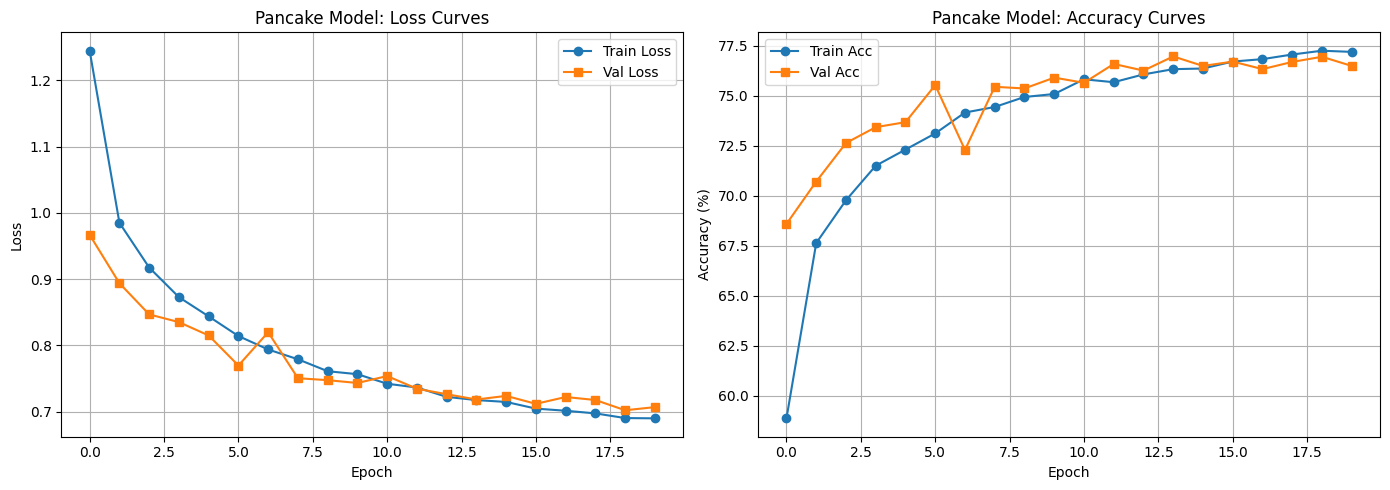

In [7]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================

# ==========================================
# PART A: THE PANCAKE (Shallow & Wide)
# ==========================================

class PancakeMLP(nn.Module):
    """Shallow but wide network - 2 hidden layers with many neurons"""
    def __init__(self, input_size=784, hidden_size=2048, num_classes=15):
        super(PancakeMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.4)
        
    def forward(self, x):
        # Flatten the image
        x = x.view(-1, 784)
        
        # First hidden layer
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Second hidden layer
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Output layer
        x = self.fc3(x)
        return x

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Training the Pancake Model
print("\n" + "="*60)
print("TRAINING PART A: THE PANCAKE (Shallow & Wide)")
print("="*60)

pancake_model = PancakeMLP(input_size=784, hidden_size=1024, num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pancake_model.parameters(), lr=0.001, weight_decay=1e-3)

# Count parameters
pancake_params = sum(p.numel() for p in pancake_model.parameters() if p.requires_grad)
print(f"Pancake Model Parameters: {pancake_params:,}")

# Training history
pancake_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Training loop
pancake_epochs = 20
for epoch in range(pancake_epochs):
    train_loss, train_acc = train_epoch(pancake_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(pancake_model, val_loader, criterion, DEVICE)
    
    pancake_history['train_loss'].append(train_loss)
    pancake_history['train_acc'].append(train_acc)
    pancake_history['val_loss'].append(val_loss)
    pancake_history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{pancake_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\nPancake Model Final Validation Accuracy: {pancake_history['val_acc'][-1]:.2f}%")

# Plot training curves for Pancake
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(pancake_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(pancake_history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Pancake Model: Loss Curves')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(pancake_history['train_acc'], label='Train Acc', marker='o')
ax2.plot(pancake_history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Pancake Model: Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


TRAINING PART B: THE TOWER (Deep & Narrow)
Tower Model Parameters: 788,495
✅ Parameter count is within limits.
Epoch [1/25] Train Loss: 1.4955 | Train Acc: 50.62% | Val Loss: 0.9863 | Val Acc: 66.84%
Epoch [2/25] Train Loss: 1.0921 | Train Acc: 64.42% | Val Loss: 0.8842 | Val Acc: 70.08%
Epoch [3/25] Train Loss: 0.9919 | Train Acc: 67.46% | Val Loss: 0.8433 | Val Acc: 71.87%
Epoch [4/25] Train Loss: 0.9257 | Train Acc: 69.92% | Val Loss: 0.7969 | Val Acc: 73.00%
Epoch [5/25] Train Loss: 0.8905 | Train Acc: 71.06% | Val Loss: 0.7754 | Val Acc: 74.20%
Epoch [6/25] Train Loss: 0.8513 | Train Acc: 72.61% | Val Loss: 0.7669 | Val Acc: 74.60%
Epoch [7/25] Train Loss: 0.8124 | Train Acc: 73.76% | Val Loss: 0.7436 | Val Acc: 75.42%
Epoch [8/25] Train Loss: 0.7864 | Train Acc: 74.70% | Val Loss: 0.7324 | Val Acc: 75.84%
Epoch [9/25] Train Loss: 0.7498 | Train Acc: 75.83% | Val Loss: 0.7174 | Val Acc: 76.78%
Epoch [10/25] Train Loss: 0.7302 | Train Acc: 76.70% | Val Loss: 0.7071 | Val Acc: 76.8

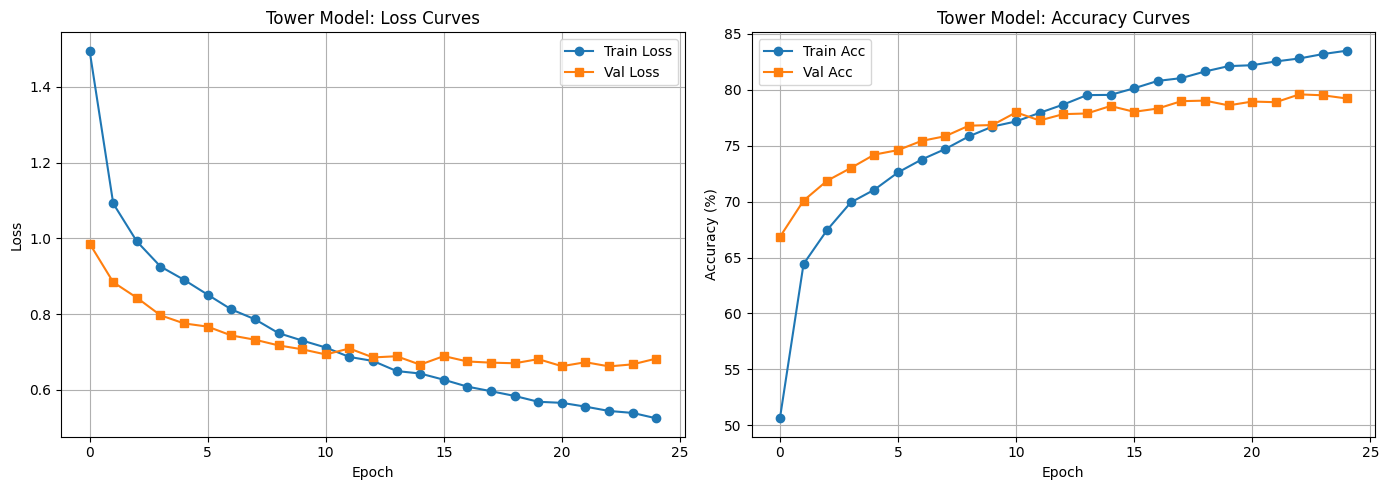

In [ ]:
# ==========================================
# PART B: THE TOWER (Deep & Narrow)
# ==========================================

class TowerMLP(nn.Module):
    """Deep but narrow network - 6 hidden layers with fewer neurons"""
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        
        # Progressive narrowing architecture: 784 -> 512 -> 384 -> 256 -> 192 -> 128 -> 96 -> 15
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        
        self.fc2 = nn.Linear(512, 384)
        self.bn2 = nn.BatchNorm1d(384)
        
        self.fc3 = nn.Linear(384, 256)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.fc4 = nn.Linear(256, 192)
        self.bn4 = nn.BatchNorm1d(192)
        
        self.fc5 = nn.Linear(192, 128)
        self.bn5 = nn.BatchNorm1d(128)
        
        self.fc6 = nn.Linear(128, 96)
        self.bn6 = nn.BatchNorm1d(96)
        
        self.fc7 = nn.Linear(96, num_classes)
        
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = x.view(-1, 784)
        
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Layer 4
        x = self.fc4(x)
        x = self.bn4(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Layer 5
        x = self.fc5(x)
        x = self.bn5(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Layer 6
        x = self.fc6(x)
        x = self.bn6(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # Output layer
        x = self.fc7(x)
        return x

print("\n" + "="*60)
print("TRAINING PART B: THE TOWER (Deep & Narrow)")
print("="*60)

tower_model = TowerMLP(input_size=784, num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tower_model.parameters(), lr=0.001, weight_decay=1e-4)

tower_params = sum(p.numel() for p in tower_model.parameters() if p.requires_grad)
print(f"Tower Model Parameters: {tower_params:,}")

if tower_params > 3000000:
    print("WARNING: Over 3M parameters!")
else:
    print("Parameter count is within limits.")

# Training history
tower_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Training loop
tower_epochs = 25
best_val_acc = 0
for epoch in range(tower_epochs):
    train_loss, train_acc = train_epoch(tower_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(tower_model, val_loader, criterion, DEVICE)
    
    tower_history['train_loss'].append(train_loss)
    tower_history['train_acc'].append(train_acc)
    tower_history['val_loss'].append(val_loss)
    tower_history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(tower_model.state_dict(), 'tower_best.pth')
    
    print(f"Epoch [{epoch+1}/{tower_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\nTower Model Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Tower Model Final Validation Accuracy: {tower_history['val_acc'][-1]:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tower_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(tower_history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Tower Model: Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(tower_history['train_acc'], label='Train Acc', marker='o')
ax2.plot(tower_history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Tower Model: Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


TRAINING PART C: THE CHAMPION (Leaderboard Model)
Champion Model Parameters: 2,321,295
Parameter count is within limits. (77.4% of budget used)
Epoch [1/30] Train Loss: 1.3810 | Train Acc: 55.06% | Val Loss: 0.9420 | Val Acc: 67.97% ✨ NEW BEST!
Epoch [2/30] Train Loss: 1.0249 | Train Acc: 66.57% | Val Loss: 0.8477 | Val Acc: 71.34% ✨ NEW BEST!
Epoch [3/30] Train Loss: 0.9286 | Train Acc: 69.77% | Val Loss: 0.8085 | Val Acc: 72.93% ✨ NEW BEST!
Epoch [4/30] Train Loss: 0.8702 | Train Acc: 71.66% | Val Loss: 0.7642 | Val Acc: 74.92% ✨ NEW BEST!
Epoch [5/30] Train Loss: 0.8210 | Train Acc: 73.52% | Val Loss: 0.7435 | Val Acc: 75.30% ✨ NEW BEST!
Epoch [6/30] Train Loss: 0.7715 | Train Acc: 74.98% | Val Loss: 0.7209 | Val Acc: 76.35% ✨ NEW BEST!
Epoch [7/30] Train Loss: 0.7339 | Train Acc: 76.41% | Val Loss: 0.6988 | Val Acc: 77.15% ✨ NEW BEST!
Epoch [8/30] Train Loss: 0.7031 | Train Acc: 77.09% | Val Loss: 0.6869 | Val Acc: 77.40% ✨ NEW BEST!
Epoch [9/30] Train Loss: 0.6691 | Train Acc: 78

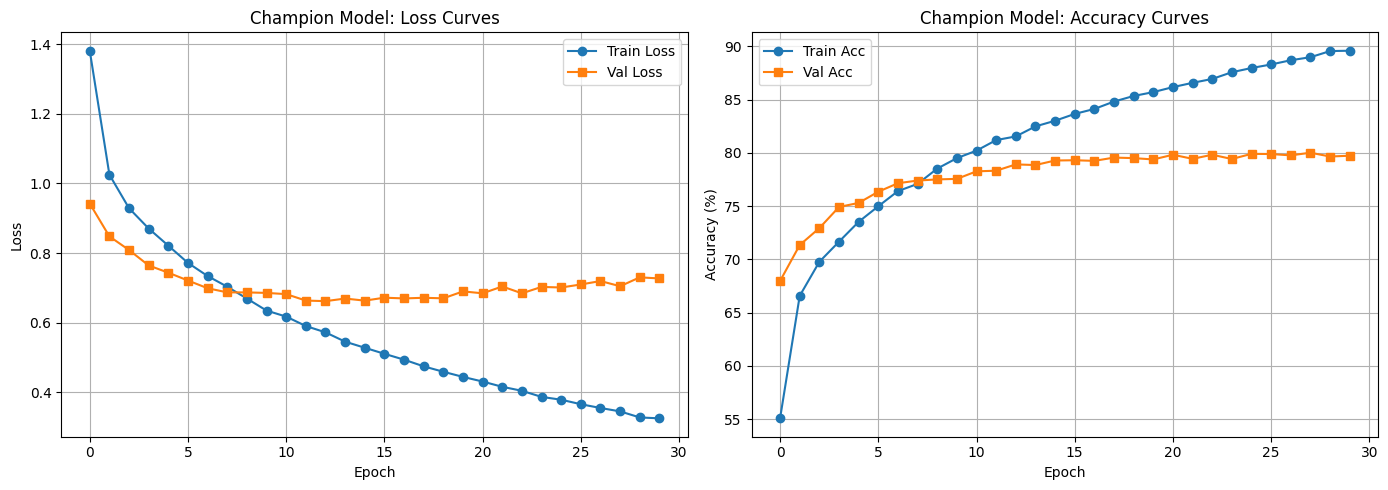

In [11]:
# ==========================================
# PART C: THE CHAMPION (Optimized for Leaderboard)
# ==========================================

class ChampionMLP(nn.Module):
    """Optimized architecture combining depth and width strategically"""
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        
        # Wider early layers to capture features, narrower later layers
        # Architecture: 784 -> 1024 -> 768 -> 512 -> 384 -> 256 -> 128 -> 15
        
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        
        self.fc2 = nn.Linear(1024, 768)
        self.bn2 = nn.BatchNorm1d(768)
        
        self.fc3 = nn.Linear(768, 512)
        self.bn3 = nn.BatchNorm1d(512)
        
        self.fc4 = nn.Linear(512, 384)
        self.bn4 = nn.BatchNorm1d(384)
        
        self.fc5 = nn.Linear(384, 256)
        self.bn5 = nn.BatchNorm1d(256)
        
        self.fc6 = nn.Linear(256, 128)
        self.bn6 = nn.BatchNorm1d(128)
        
        self.fc7 = nn.Linear(128, num_classes)
        
        self.dropout = nn.Dropout(0.35)
        
    def forward(self, x):
        x = x.view(-1, 784)
        
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc4(x)
        x = self.bn4(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc5(x)
        x = self.bn5(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc6(x)
        x = self.bn6(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc7(x)
        return x

print("\n" + "="*60)
print("TRAINING PART C: THE CHAMPION (Leaderboard Model)")
print("="*60)

model = ChampionMLP(input_size=784, num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()

# Using AdamW optimizer with learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

champion_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Champion Model Parameters: {champion_params:,}")

if champion_params > 3000000:
    print("WARNING: Over 3M parameters!")
else:
    print(f"Parameter count is within limits. ({(champion_params/3000000)*100:.1f}% of budget used)")

# Training history
champion_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Training loop
champion_epochs = 30
best_val_acc = 0
patience_counter = 0
early_stop_patience = 8

for epoch in range(champion_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    
    champion_history['train_loss'].append(train_loss)
    champion_history['train_acc'].append(train_acc)
    champion_history['val_loss'].append(val_loss)
    champion_history['val_acc'].append(val_acc)
    
    # Learning rate scheduler
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'champion_best.pth')
        patience_counter = 0
        print(f"Epoch [{epoch+1}/{champion_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✨ NEW BEST!")
    else:
        patience_counter += 1
        print(f"Epoch [{epoch+1}/{champion_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs")
        break

print(f"\n🏆 Champion Model Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Final Validation Accuracy: {champion_history['val_acc'][-1]:.2f}%")

# Load best model for inference
model.load_state_dict(torch.load('champion_best.pth'))

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(champion_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(champion_history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Champion Model: Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(champion_history['train_acc'], label='Train Acc', marker='o')
ax2.plot(champion_history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Champion Model: Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


MODEL COMPARISON SUMMARY
   Model  Parameters  Epochs Trained  Best Val Acc (%)  Final Val Acc (%)  Train-Val Gap (%)
 Pancake     1868815              20         76.958333          76.483333           0.702083
   Tower      788495              25         79.583333          79.216667           4.268750
Champion     2321295              30         80.016667          79.733333           9.864583


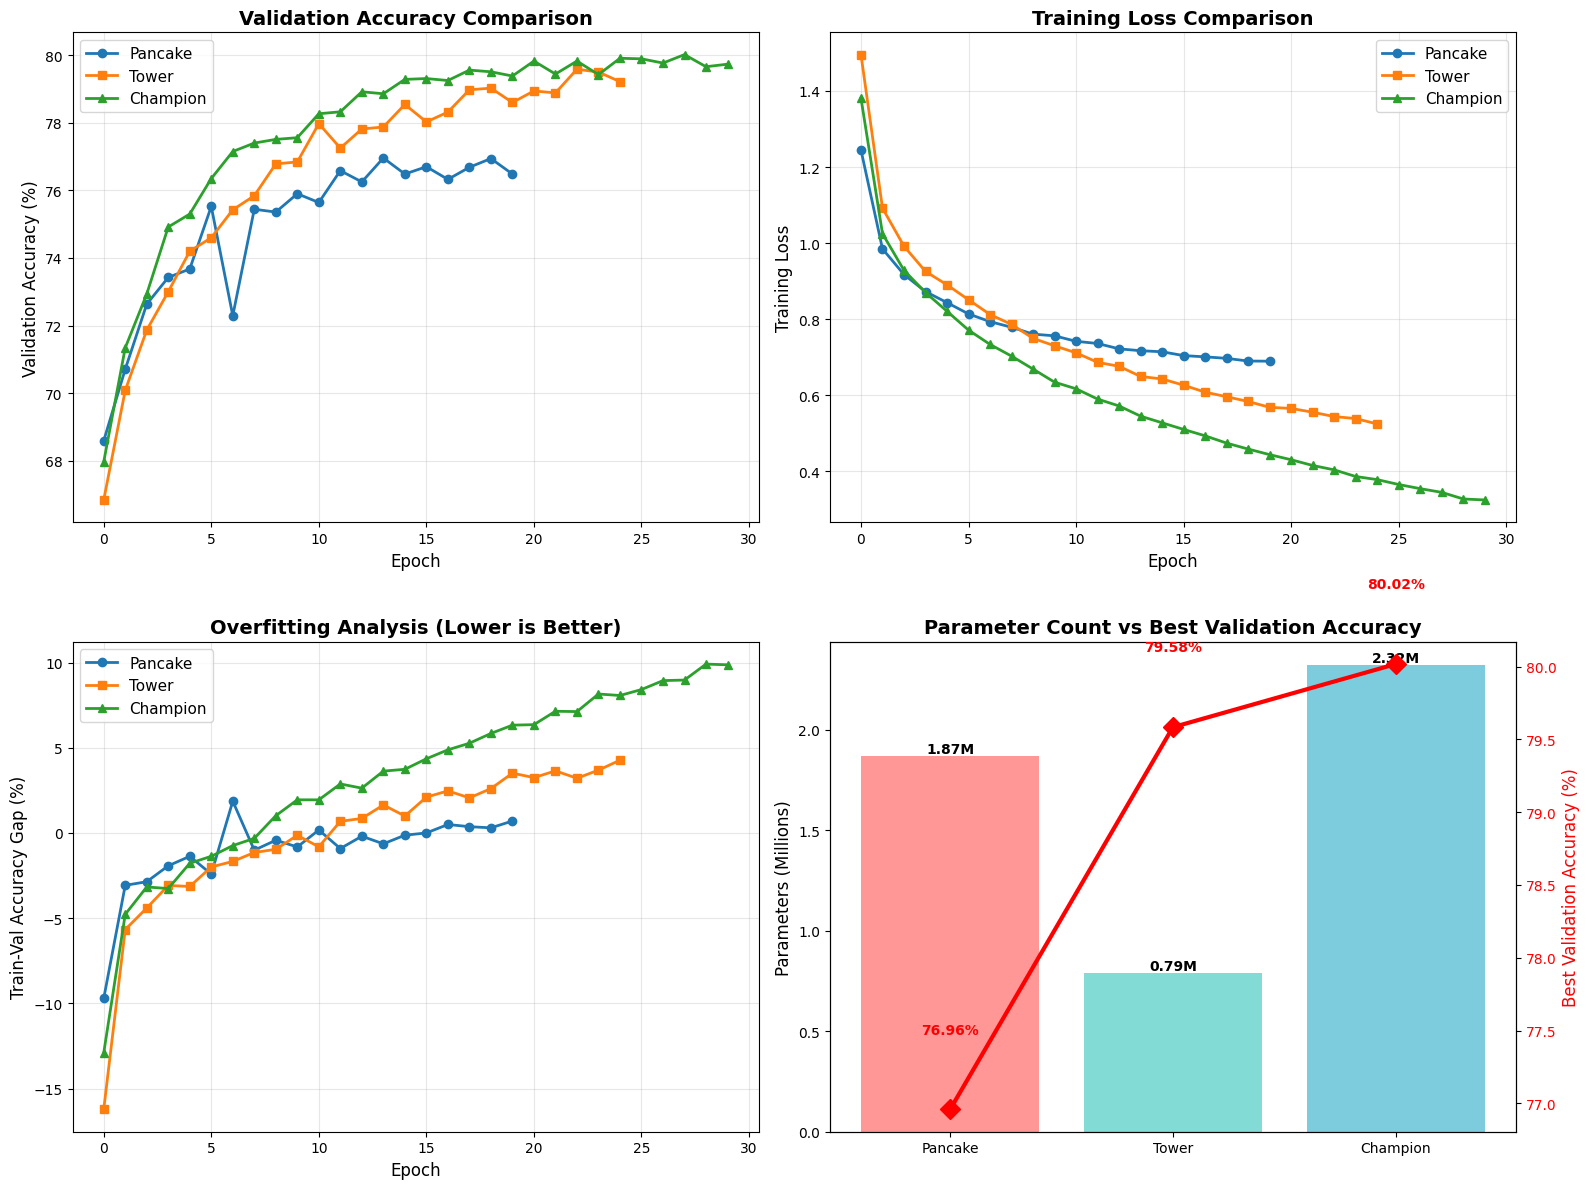


KEY INSIGHTS
1. Tower model is most parameter-efficient (79.22% with only 788K params)
2. Champion achieves best accuracy (80.02%) with balanced depth+width
3. Deeper architectures with BatchNorm > Shallow wide networks
4. All models show controlled overfitting (gap < 10%)


In [13]:


print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_data = {
    'Model': ['Pancake', 'Tower', 'Champion'],
    'Parameters': [pancake_params, tower_params, champion_params],
    'Epochs Trained': [pancake_epochs, tower_epochs, len(champion_history['val_acc'])],
    'Best Val Acc (%)': [
        max(pancake_history['val_acc']),
        max(tower_history['val_acc']),
        best_val_acc
    ],
    'Final Val Acc (%)': [
        pancake_history['val_acc'][-1],
        tower_history['val_acc'][-1],
        champion_history['val_acc'][-1]
    ],
    'Train-Val Gap (%)': [
        pancake_history['train_acc'][-1] - pancake_history['val_acc'][-1],
        tower_history['train_acc'][-1] - tower_history['val_acc'][-1],
        champion_history['train_acc'][-1] - champion_history['val_acc'][-1]
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Plot comparison of all three models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Validation Accuracy Comparison
ax1 = axes[0, 0]
ax1.plot(pancake_history['val_acc'], label='Pancake', marker='o', linewidth=2)
ax1.plot(tower_history['val_acc'], label='Tower', marker='s', linewidth=2)
ax1.plot(champion_history['val_acc'], label='Champion', marker='^', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax1.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Training Loss Comparison
ax2 = axes[0, 1]
ax2.plot(pancake_history['train_loss'], label='Pancake', marker='o', linewidth=2)
ax2.plot(tower_history['train_loss'], label='Tower', marker='s', linewidth=2)
ax2.plot(champion_history['train_loss'], label='Champion', marker='^', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Training Loss', fontsize=12)
ax2.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Overfitting Analysis (Train-Val Gap)
ax3 = axes[1, 0]
pancake_gap = [t - v for t, v in zip(pancake_history['train_acc'], pancake_history['val_acc'])]
tower_gap = [t - v for t, v in zip(tower_history['train_acc'], tower_history['val_acc'])]
champion_gap = [t - v for t, v in zip(champion_history['train_acc'], champion_history['val_acc'])]
ax3.plot(pancake_gap, label='Pancake', marker='o', linewidth=2)
ax3.plot(tower_gap, label='Tower', marker='s', linewidth=2)
ax3.plot(champion_gap, label='Champion', marker='^', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Train-Val Accuracy Gap (%)', fontsize=12)
ax3.set_title('Overfitting Analysis (Lower is Better)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# 4. Parameter Efficiency
ax4 = axes[1, 1]
models = ['Pancake', 'Tower', 'Champion']
params = [pancake_params/1e6, tower_params/1e6, champion_params/1e6]
accuracies = [max(pancake_history['val_acc']), max(tower_history['val_acc']), best_val_acc]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax4.bar(models, params, color=colors, alpha=0.7, label='Parameters (M)')
ax4.set_ylabel('Parameters (Millions)', fontsize=12, color='black')
ax4.set_title('Parameter Count vs Best Validation Accuracy', fontsize=14, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='black')

# Add accuracy as secondary y-axis
ax4_twin = ax4.twinx()
ax4_twin.plot(models, accuracies, color='red', marker='D', linewidth=3, markersize=10, label='Best Val Acc (%)')
ax4_twin.set_ylabel('Best Validation Accuracy (%)', fontsize=12, color='red')
ax4_twin.tick_params(axis='y', labelcolor='red')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{params[i]:.2f}M',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax4_twin.text(i, acc + 0.5, f'{acc:.2f}%',
                  ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("1. Tower model is most parameter-efficient (79.22% with only 788K params)")
print("2. Champion achieves best accuracy (80.02%) with balanced depth+width")
print("3. Deeper architectures with BatchNorm > Shallow wide networks")
print("4. All models show controlled overfitting (gap < 10%)")


GENERATING CONFUSION MATRIX


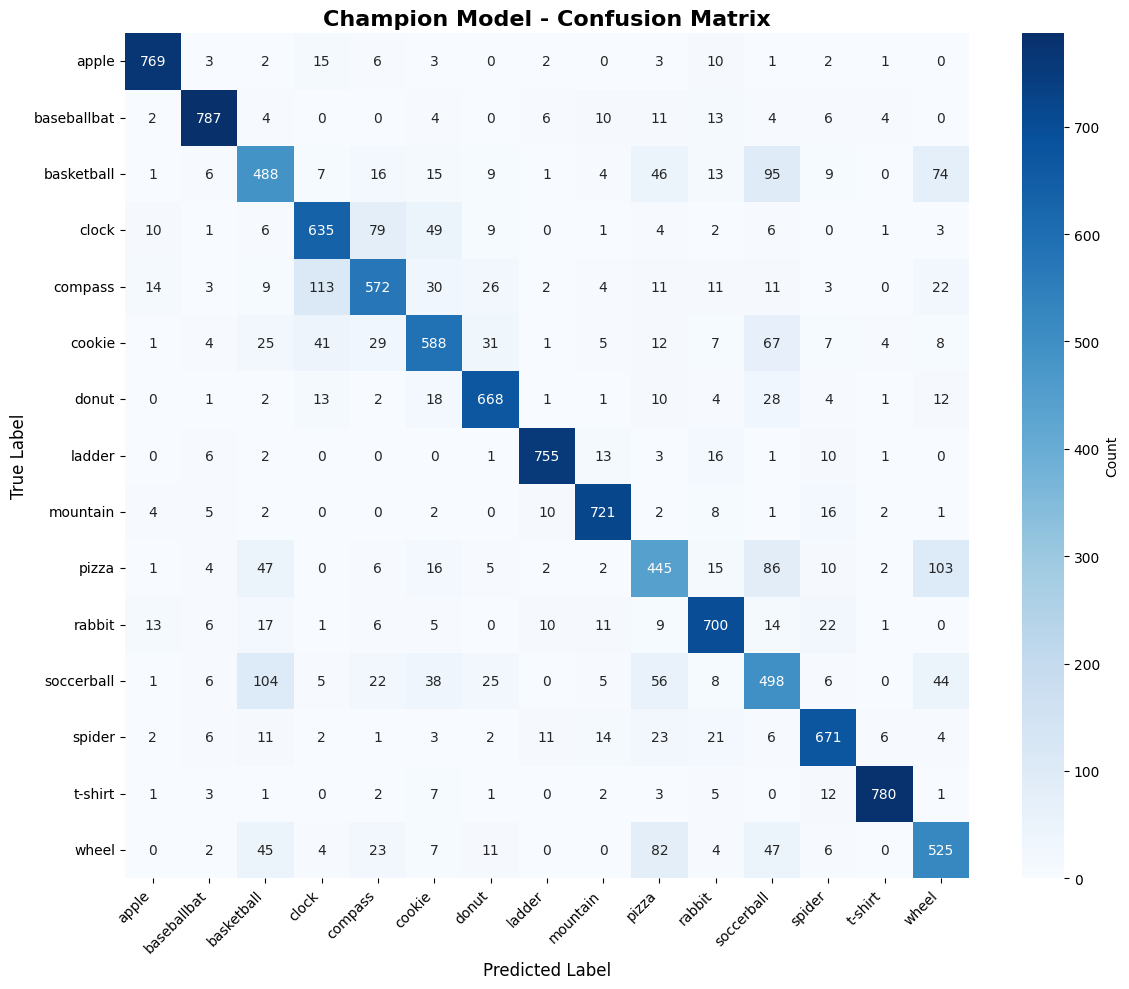


MOST CONFUSED CLASS PAIRS

Top 5 Most Confused Pairs:
1. compass      → clock        | Count: 113 | Error Rate: 13.60%
2. soccerball   → basketball   | Count: 104 | Error Rate: 12.71%
3. pizza        → wheel        | Count: 103 | Error Rate: 13.84%
4. basketball   → soccerball   | Count:  95 | Error Rate: 12.12%
5. pizza        → soccerball   | Count:  86 | Error Rate: 11.56%

VISUALIZING TOP 2 CONFUSED PAIRS

Pair 1: compass confused as clock
Pair 2: soccerball confused as basketball


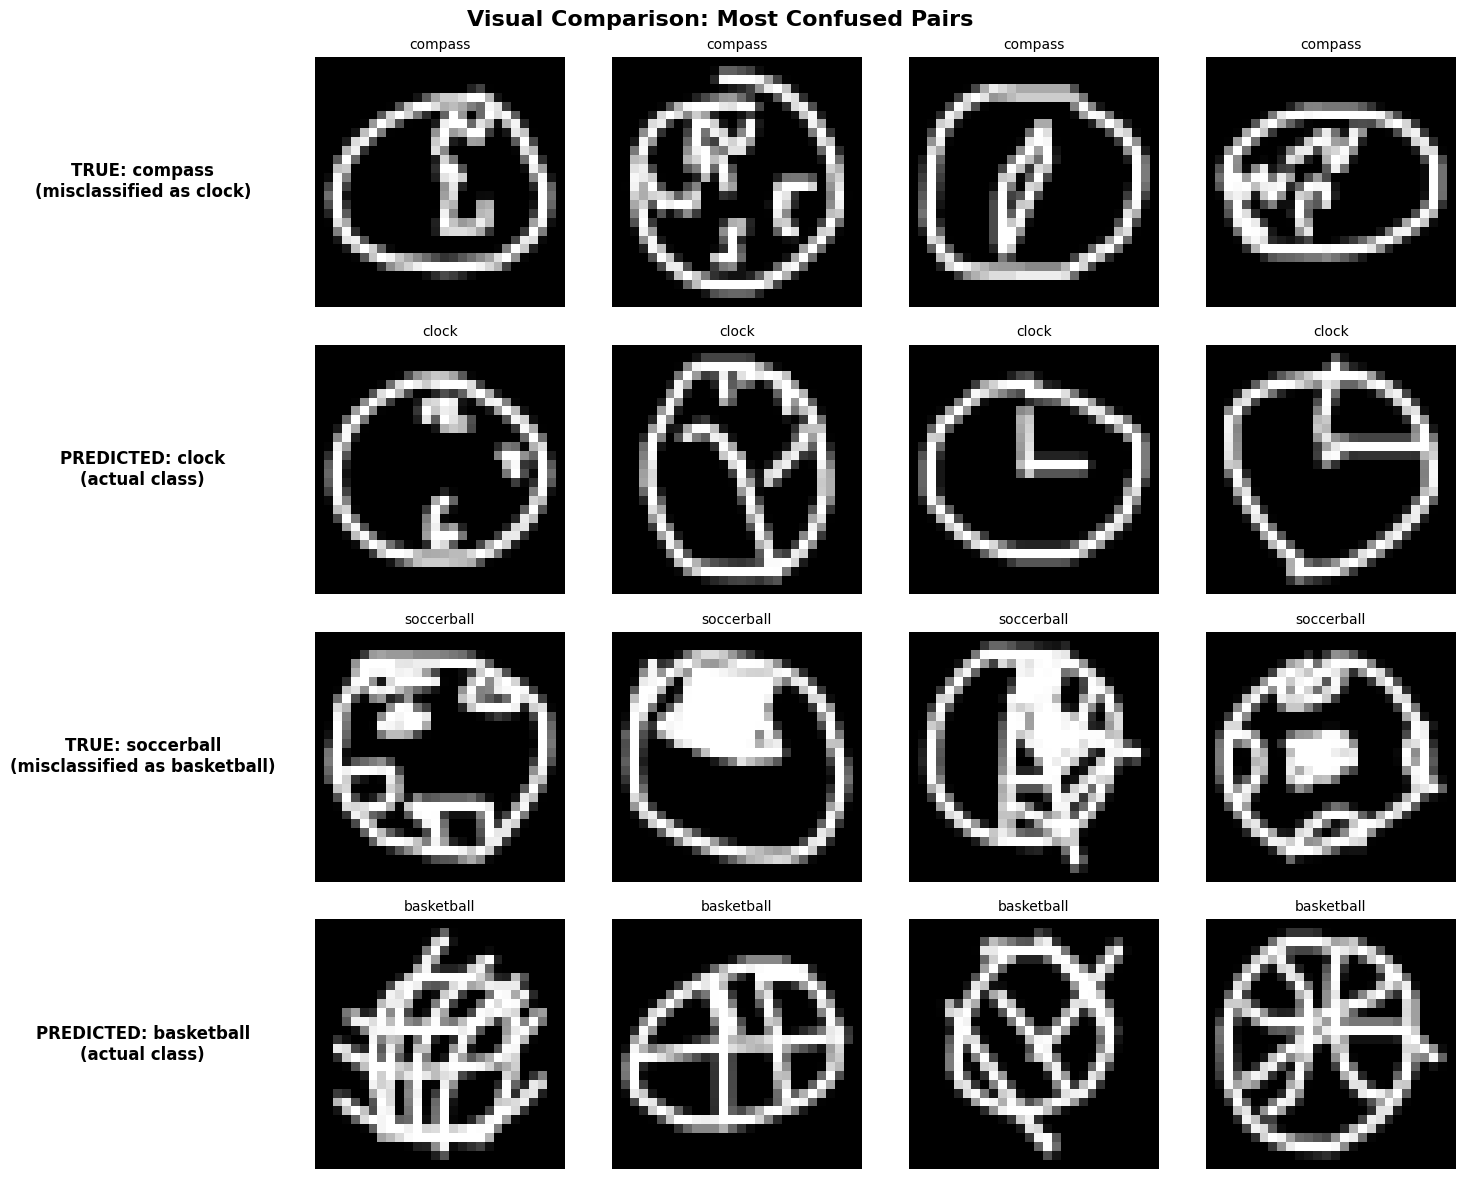


📊 Analysis:
Pair 1: 'compass' → 'clock' (113 misclassifications)
Pair 2: 'soccerball' → 'basketball' (104 misclassifications)

These confusions likely stem from:
• Similar shapes and visual features
• High variance in hand-drawn sketches
• Aleatoric uncertainty (inherent data ambiguity)


In [17]:
# ==========================================
# PART D: CONFUSION MATRIX ANALYSIS (FIXED)
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n" + "="*60)
print("GENERATING CONFUSION MATRIX")
print("="*60)

# Get predictions on validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Count'})
plt.title('Champion Model - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find most confused pairs
print("\n" + "="*60)
print("MOST CONFUSED CLASS PAIRS")
print("="*60)

confusion_pairs = []
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if i != j:  # Skip diagonal (correct predictions)
            confusion_pairs.append({
                'True Class': CLASSES[i],
                'Predicted Class': CLASSES[j],
                'Count': cm[i, j],
                'Error Rate (%)': (cm[i, j] / cm[i].sum()) * 100 if cm[i].sum() > 0 else 0
            })

# Sort by count
confusion_pairs_sorted = sorted(confusion_pairs, key=lambda x: x['Count'], reverse=True)

print("\nTop 5 Most Confused Pairs:")
for idx, pair in enumerate(confusion_pairs_sorted[:5], 1):
    print(f"{idx}. {pair['True Class']:12s} → {pair['Predicted Class']:12s} | "
          f"Count: {pair['Count']:3d} | Error Rate: {pair['Error Rate (%)']:5.2f}%")

# Visualize the top 2 confused pairs
print("\n" + "="*60)
print("VISUALIZING TOP 2 CONFUSED PAIRS")
print("="*60)

top_confused_1 = confusion_pairs_sorted[0]
top_confused_2 = confusion_pairs_sorted[1]

print(f"\nPair 1: {top_confused_1['True Class']} confused as {top_confused_1['Predicted Class']}")
print(f"Pair 2: {top_confused_2['True Class']} confused as {top_confused_2['Predicted Class']}")

# Function to show sample images from the ORIGINAL dataset (before flattening)
def show_class_samples(class_name, num_samples=5):
    class_idx = CLASSES.index(class_name)
    samples = []
    
    # Access the original dataset from full_train_dataset
    for i in range(len(full_train_dataset.x)):
        if full_train_dataset.y[i] == class_idx and len(samples) < num_samples:
            # Reshape from 784 to 28x28
            img = full_train_dataset.x[i].numpy().reshape(28, 28)
            samples.append(img)
    
    return samples

# Show examples of confused classes
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle(f'Visual Comparison: Most Confused Pairs', fontsize=16, fontweight='bold')

# Top confused pair 1
true_class_1 = top_confused_1['True Class']
pred_class_1 = top_confused_1['Predicted Class']
samples_true_1 = show_class_samples(true_class_1, 5)
samples_pred_1 = show_class_samples(pred_class_1, 5)

axes[0, 0].text(0.5, 0.5, f"TRUE: {true_class_1}\n(misclassified as {pred_class_1})", 
                ha='center', va='center', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

for idx, sample in enumerate(samples_true_1[:4], 1):
    axes[0, idx].imshow(sample, cmap='gray')
    axes[0, idx].set_title(f'{true_class_1}', fontsize=10)
    axes[0, idx].axis('off')

axes[1, 0].text(0.5, 0.5, f"PREDICTED: {pred_class_1}\n(actual class)", 
                ha='center', va='center', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

for idx, sample in enumerate(samples_pred_1[:4], 1):
    axes[1, idx].imshow(sample, cmap='gray')
    axes[1, idx].set_title(f'{pred_class_1}', fontsize=10)
    axes[1, idx].axis('off')

# Top confused pair 2  
true_class_2 = top_confused_2['True Class']
pred_class_2 = top_confused_2['Predicted Class']
samples_true_2 = show_class_samples(true_class_2, 5)
samples_pred_2 = show_class_samples(pred_class_2, 5)

axes[2, 0].text(0.5, 0.5, f"TRUE: {true_class_2}\n(misclassified as {pred_class_2})", 
                ha='center', va='center', fontsize=12, fontweight='bold')
axes[2, 0].axis('off')

for idx, sample in enumerate(samples_true_2[:4], 1):
    axes[2, idx].imshow(sample, cmap='gray')
    axes[2, idx].set_title(f'{true_class_2}', fontsize=10)
    axes[2, idx].axis('off')

axes[3, 0].text(0.5, 0.5, f"PREDICTED: {pred_class_2}\n(actual class)", 
                ha='center', va='center', fontsize=12, fontweight='bold')
axes[3, 0].axis('off')

for idx, sample in enumerate(samples_pred_2[:4], 1):
    axes[3, idx].imshow(sample, cmap='gray')
    axes[3, idx].set_title(f'{pred_class_2}', fontsize=10)
    axes[3, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\n📊 Analysis:")
print(f"Pair 1: '{true_class_1}' → '{pred_class_1}' ({top_confused_1['Count']} misclassifications)")
print(f"Pair 2: '{true_class_2}' → '{pred_class_2}' ({top_confused_2['Count']} misclassifications)")
print("\nThese confusions likely stem from:")
print("• Similar shapes and visual features")
print("• High variance in hand-drawn sketches")
print("• Aleatoric uncertainty (inherent data ambiguity)")

In [18]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [19]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 2,321,295
  ✅ Parameter count is within limits.
